# T1 - Comparacao de classificadores

**Disciplina:** CIC407 - Inteligencia Artificial e Aplicacoes  
**Professor:** Evandro Ferraz  
**Integrantes (ordem alfabetica):**

1. Edgar Kodjoglamian Messias - 23.01612-4
2. Felipe Carillo - 23.00765-6
3. Gabriel da Silva Merola - 23.00825-3
4. Isaías Cano Bello da Luz - 23.00257-3
5. Marcelo Zoletti - 23.00171-2
6. Yuri Alves Drapack - 23.00243-3

Este notebook compara tres algoritmos de classificacao para prever a situacao
academica final de estudantes: `Dropout`, `Enrolled` ou `Graduate`.

## Como executar

1. Baixe o arquivo `data.csv` da base [Students Dropout and Academic Success](https://www.kaggle.com/datasets/missionjee/students-dropout-and-academic-success-dataset).
2. Salve-o em `data/data.csv` relativo a este arquivo.
3. Instale as bibliotecas: `pip install pandas numpy scikit-learn matplotlib seaborn`.
4. Execute todas as celulas em ordem. O projeto usa `random_state=42` e, portanto, e reproduzivel.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
TEST_SIZE = 0.20
ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = ROOT / "data" / "data.csv"
KAGGLE_URL = "https://www.kaggle.com/datasets/missionjee/students-dropout-and-academic-success-dataset"


def show_table(data, rows=10):
    """Exibe um DataFrame no notebook e tambem o torna legivel ao executar o .py."""
    if isinstance(data, pd.DataFrame):
        display(data.head(rows))
    else:
        display(data)




## 1. Leitura e validacao da base

A base contem informacoes demograficas, de ingresso, financeiras e de desempenho no primeiro e no segundo semestres. A coluna alvo e `Target`.


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo nao encontrado: {DATA_PATH}. Baixe a base do Kaggle e salve-a em data/data.csv."
    )

df = pd.read_csv(DATA_PATH, sep=";")
# O arquivo possui um tab no nome de uma coluna; esta normalizacao evita erros e nao altera os dados.
df.columns = df.columns.str.replace(r"\s+", " ", regex=True).str.strip()

EXPECTED_CLASSES = {"Dropout", "Enrolled", "Graduate"}
assert "Target" in df.columns, "A coluna Target e obrigatoria."
assert set(df["Target"].unique()) == EXPECTED_CLASSES, "As tres classes esperadas nao foram encontradas."
assert df.isna().sum().sum() == 0, "Esta analise espera a versao sem valores ausentes da base."

print(f"Arquivo: {DATA_PATH.name}")
print(f"Registros: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print(f"Valores ausentes: {df.isna().sum().sum()} | Linhas duplicadas: {df.duplicated().sum()}")
show_table(df, rows=5)



Arquivo: data.csv
Registros: 4,424 | Colunas: 37
Valores ausentes: 0 | Linhas duplicadas: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Variaveis preditivas e variavel alvo

`Target` e uma variavel qualitativa com tres classes. Todas as demais 36 colunas serao usadas como preditoras, conforme o recorte definido para este trabalho.


,coluna,tipo,n_unicos,nulos,papel
0,Marital status,int64,6,0,preditora
1,Application mode,int64,18,0,preditora
2,Application order,int64,8,0,preditora
3,Course,int64,17,0,preditora
4,Daytime/evening attendance,int64,2,0,preditora
5,Previous qualification,int64,17,0,preditora
6,Previous qualification (grade),float64,101,0,preditora
7,Nacionality,int64,21,0,preditora
8,Mother's qualification,int64,29,0,preditora
9,Father's qualification,int64,34,0,preditora


,classe,quantidade,percentual
0,Graduate,2209,49.932188
1,Dropout,1421,32.120253
2,Enrolled,794,17.947559


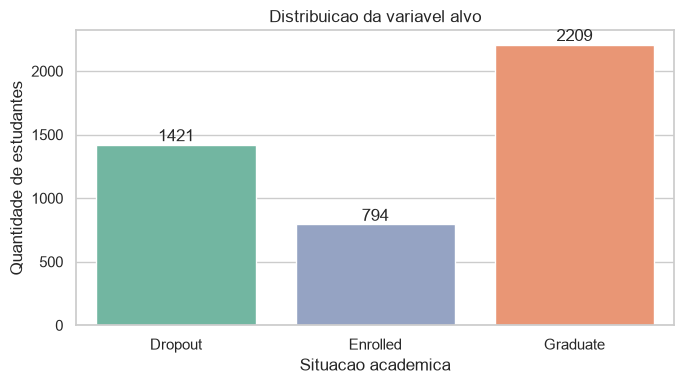

In [3]:
target_column = "Target"
X = df.drop(columns=target_column).copy()
y = df[target_column].copy()

assert target_column not in X.columns
assert X.shape[1] == 36

column_summary = pd.DataFrame(
    {
        "coluna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "n_unicos": df.nunique().values,
        "nulos": df.isna().sum().values,
        "papel": ["alvo" if col == target_column else "preditora" for col in df.columns],
    }
)
show_table(column_summary, rows=len(column_summary))

class_distribution = (
    y.value_counts()
    .rename_axis("classe")
    .reset_index(name="quantidade")
    .assign(percentual=lambda table: 100 * table["quantidade"] / len(y))
)
show_table(class_distribution, rows=3)

plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df,
    x=target_column,
    hue=target_column,
    order=["Dropout", "Enrolled", "Graduate"],
    palette="Set2",
    legend=False,
)
ax.set(title="Distribuicao da variavel alvo", xlabel="Situacao academica", ylabel="Quantidade de estudantes")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()



## 2. Preparacao dos dados

Algumas colunas sao codigos numericos de categorias, por exemplo curso, nacionalidade e modalidade de candidatura. Elas serao transformadas por one-hot encoding. As medidas quantitativas permanecem numericas. A transformacao e mantida dentro de cada pipeline para que ela seja ajustada somente com os dados de treino, evitando vazamento de dados.


In [4]:
categorical_columns = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]
numeric_columns = [column for column in X.columns if column not in categorical_columns]

assert set(categorical_columns).issubset(X.columns)
assert not set(categorical_columns).intersection(numeric_columns)
assert len(categorical_columns) + len(numeric_columns) == X.shape[1]

print(f"Colunas categoricas codificadas: {len(categorical_columns)}")
print(f"Colunas quantitativas: {len(numeric_columns)}")
print("\nExemplos de colunas categoricas:", categorical_columns[:6])
print("Exemplos de colunas quantitativas:", numeric_columns[:6])



Colunas categoricas codificadas: 17
Colunas quantitativas: 19

Exemplos de colunas categoricas: ['Marital status', 'Application mode', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality']
Exemplos de colunas quantitativas: ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)']


## 3. Divisao treino/teste

A mesma divisao estratificada de 80% para treino e 20% para teste sera usada nos tres algoritmos. Assim, a comparacao e justa e reproduzivel.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_distribution = pd.DataFrame(
    {
        "base_completa (%)": (y.value_counts(normalize=True) * 100),
        "treino (%)": (y_train.value_counts(normalize=True) * 100),
        "teste (%)": (y_test.value_counts(normalize=True) * 100),
    }
).reindex(["Dropout", "Enrolled", "Graduate"])
show_table(split_distribution.round(2), rows=3)

assert len(X_train) + len(X_test) == len(X)
assert set(y_train.unique()) == EXPECTED_CLASSES == set(y_test.unique())
assert np.allclose(
    y_train.value_counts(normalize=True).sort_index(),
    y.value_counts(normalize=True).sort_index(),
    atol=0.01,
), "A estratificacao nao preservou adequadamente as proporcoes de classe."

print(f"Treino: {len(X_train)} registros | Teste: {len(X_test)} registros")



,base_completa (%),treino (%),teste (%)
Target,,,
Dropout,32.12,32.13,32.09
Enrolled,17.95,17.94,17.97
Graduate,49.93,49.93,49.94


Treino: 3539 registros | Teste: 885 registros


## 4. Pipelines e treinamento

- **Arvore de Decisao:** interpreta regras de decisao e nao precisa de normalizacao.
- **KNN:** classifica pela proximidade entre exemplos e exige escalonamento das variaveis quantitativas.
- **SVM:** busca fronteiras de separacao entre classes e tambem se beneficia da normalizacao.



Arvore de Decisao
              precision    recall  f1-score   support

     Dropout       0.68      0.68      0.68       284
    Enrolled       0.33      0.36      0.34       159
    Graduate       0.80      0.77      0.79       442

    accuracy                           0.67       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.68      0.67      0.67       885



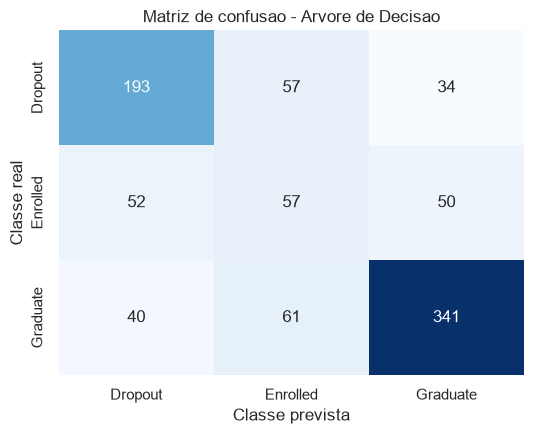


KNN (k=5)
              precision    recall  f1-score   support

     Dropout       0.75      0.63      0.69       284
    Enrolled       0.41      0.28      0.33       159
    Graduate       0.73      0.89      0.80       442

    accuracy                           0.70       885
   macro avg       0.63      0.60      0.61       885
weighted avg       0.68      0.70      0.68       885



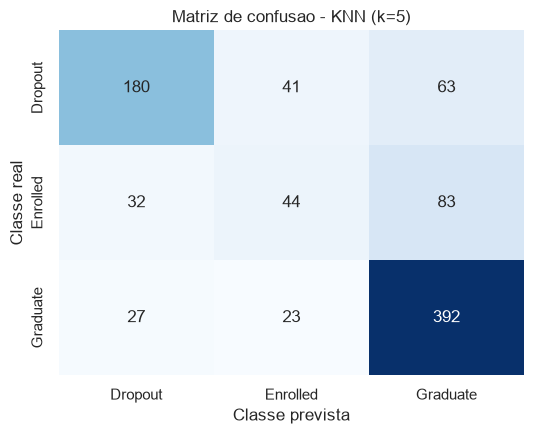


SVM (RBF)
              precision    recall  f1-score   support

     Dropout       0.81      0.72      0.76       284
    Enrolled       0.53      0.37      0.44       159
    Graduate       0.79      0.93      0.86       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



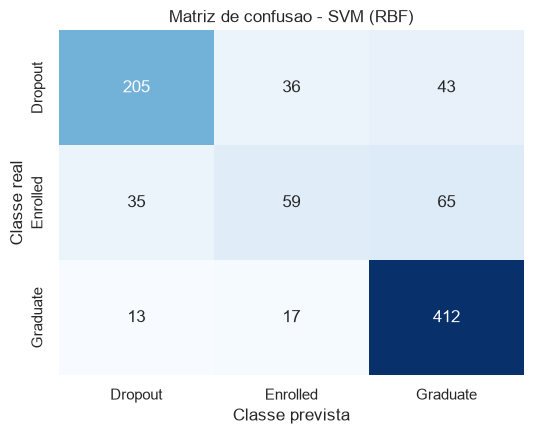

In [6]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
        ("numericas", "passthrough", numeric_columns),
    ],
    remainder="drop",
)

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
        ("numericas", StandardScaler(), numeric_columns),
    ],
    remainder="drop",
)

models = {
    "Arvore de Decisao": Pipeline(
        steps=[
            ("preprocessamento", tree_preprocessor),
            ("modelo", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]
    ),
    "KNN (k=5)": Pipeline(
        steps=[
            ("preprocessamento", scaled_preprocessor),
            ("modelo", KNeighborsClassifier(n_neighbors=5)),
        ]
    ),
    "SVM (RBF)": Pipeline(
        steps=[
            ("preprocessamento", scaled_preprocessor),
            ("modelo", SVC(kernel="rbf", C=1.0, gamma="scale")),
        ]
    ),
}

class_order = ["Dropout", "Enrolled", "Graduate"]
predictions = {}
reports = {}
metrics_rows = []

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[model_name] = y_pred

    matrix = confusion_matrix(y_test, y_pred, labels=class_order)
    assert len(y_pred) == len(y_test)
    assert matrix.shape == (3, 3)

    report = classification_report(y_test, y_pred, labels=class_order, output_dict=True, zero_division=0)
    reports[model_name] = report
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    metrics_rows.append(
        {
            "modelo": model_name,
            "acuracia": accuracy_score(y_test, y_pred),
            "precision_macro": precision,
            "recall_macro": recall,
            "f1_macro": f1_macro,
        }
    )

    print(f"\n{'=' * 68}\n{model_name}")
    print(classification_report(y_test, y_pred, labels=class_order, zero_division=0))
    figure, axis = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_order,
        yticklabels=class_order,
        ax=axis,
    )
    axis.set(
        title=f"Matriz de confusao - {model_name}",
        xlabel="Classe prevista",
        ylabel="Classe real",
    )
    plt.tight_layout()
    plt.show()



## 5. Comparacao dos resultados

Como a base possui classes de tamanhos diferentes, a metrica principal sera o F1-macro: ela da o mesmo peso para cada classe, inclusive `Enrolled`, que e a menor. A acuracia e mostrada como medida complementar.


,modelo,acuracia,precision_macro,recall_macro,f1_macro
0,SVM (RBF),76.38%,70.98%,67.50%,68.52%
1,KNN (k=5),69.60%,62.97%,59.91%,60.60%
2,Arvore de Decisao,66.78%,60.18%,60.32%,60.21%


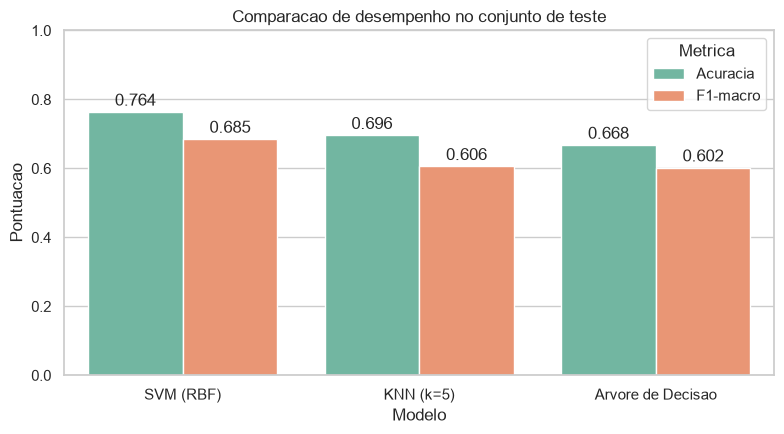

In [7]:
comparison = (
    pd.DataFrame(metrics_rows)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
show_table(
    comparison.style.format(
        {
            "acuracia": "{:.2%}",
            "precision_macro": "{:.2%}",
            "recall_macro": "{:.2%}",
            "f1_macro": "{:.2%}",
        }
    ),
    rows=3,
)

plot_data = comparison.melt(
    id_vars="modelo",
    value_vars=["acuracia", "f1_macro"],
    var_name="metrica",
    value_name="valor",
)
plot_data["metrica"] = plot_data["metrica"].map(
    {"acuracia": "Acuracia", "f1_macro": "F1-macro"}
)
plt.figure(figsize=(8, 4.5))
axis = sns.barplot(data=plot_data, x="modelo", y="valor", hue="metrica", palette="Set2")
axis.set(title="Comparacao de desempenho no conjunto de teste", xlabel="Modelo", ylabel="Pontuacao")
axis.set_ylim(0, 1)
axis.legend(title="Metrica")
for container in axis.containers:
    axis.bar_label(container, fmt="%.3f", padding=2)
plt.tight_layout()
plt.show()



## 6. Predicao de novos exemplos

Os tres registros abaixo sao perfis hipoteticos completos. Eles partem de valores modais validos da base para campos de contexto e recebem valores coerentes com cada situacao academica. Um ajuste decimal minimo em `Admission grade` garante que nenhum perfil seja uma linha original da base.


In [8]:
prototype = {column: X[column].mode().iloc[0] for column in X.columns}


def create_profile(name, changes, unique_offset):
    profile = prototype.copy()
    profile.update(changes)
    profile["Admission grade"] = float(profile["Admission grade"]) + unique_offset
    return name, profile


profiles = dict(
    [
        create_profile(
            "Desempenho forte",
            {
                "Age at enrollment": 19,
                "Scholarship holder": 1,
                "Debtor": 0,
                "Tuition fees up to date": 1,
                "Curricular units 1st sem (enrolled)": 6,
                "Curricular units 1st sem (evaluations)": 6,
                "Curricular units 1st sem (approved)": 6,
                "Curricular units 1st sem (grade)": 15.5,
                "Curricular units 1st sem (without evaluations)": 0,
                "Curricular units 2nd sem (enrolled)": 6,
                "Curricular units 2nd sem (evaluations)": 6,
                "Curricular units 2nd sem (approved)": 6,
                "Curricular units 2nd sem (grade)": 15.8,
                "Curricular units 2nd sem (without evaluations)": 0,
            },
            0.01,
        ),
        create_profile(
            "Risco de evasao",
            {
                "Age at enrollment": 24,
                "Scholarship holder": 0,
                "Debtor": 1,
                "Tuition fees up to date": 0,
                "Curricular units 1st sem (enrolled)": 6,
                "Curricular units 1st sem (evaluations)": 3,
                "Curricular units 1st sem (approved)": 0,
                "Curricular units 1st sem (grade)": 0.0,
                "Curricular units 1st sem (without evaluations)": 3,
                "Curricular units 2nd sem (enrolled)": 6,
                "Curricular units 2nd sem (evaluations)": 2,
                "Curricular units 2nd sem (approved)": 0,
                "Curricular units 2nd sem (grade)": 0.0,
                "Curricular units 2nd sem (without evaluations)": 4,
            },
            0.02,
        ),
        create_profile(
            "Situacao intermediaria",
            {
                "Age at enrollment": 22,
                "Scholarship holder": 0,
                "Debtor": 0,
                "Tuition fees up to date": 1,
                "Curricular units 1st sem (enrolled)": 6,
                "Curricular units 1st sem (evaluations)": 5,
                "Curricular units 1st sem (approved)": 4,
                "Curricular units 1st sem (grade)": 11.5,
                "Curricular units 1st sem (without evaluations)": 1,
                "Curricular units 2nd sem (enrolled)": 6,
                "Curricular units 2nd sem (evaluations)": 5,
                "Curricular units 2nd sem (approved)": 4,
                "Curricular units 2nd sem (grade)": 11.2,
                "Curricular units 2nd sem (without evaluations)": 1,
            },
            0.03,
        ),
    ]
)

new_examples = pd.DataFrame.from_dict(profiles, orient="index")[X.columns]
assert list(new_examples.columns) == list(X.columns)
assert not new_examples.duplicated().any()
assert not new_examples.apply(lambda row: (X == row).all(axis=1).any(), axis=1).any()

profile_features = [
    "Age at enrollment",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
]
show_table(new_examples[profile_features], rows=3)

new_predictions = pd.DataFrame(index=new_examples.index)
for model_name, pipeline in models.items():
    new_predictions[model_name] = pipeline.predict(new_examples)
show_table(new_predictions, rows=3)



,Age at enrollment,Scholarship holder,Debtor,Tuition fees up to date,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade)
Desempenho forte,19,1,0,1,6,15.5,6,15.8
Risco de evasao,24,0,1,0,0,0.0,0,0.0
Situacao intermediaria,22,0,0,1,4,11.5,4,11.2


,Arvore de Decisao,KNN (k=5),SVM (RBF)
Desempenho forte,Graduate,Graduate,Graduate
Risco de evasao,Dropout,Dropout,Dropout
Situacao intermediaria,Enrolled,Graduate,Enrolled


## 7. Conclusao

A conclusao abaixo e gerada a partir das metricas observadas neste experimento. Ela deve ser revisada pelo grupo apos a execucao e antes da entrega, para que todos saibam explicala na apresentacao.


In [9]:
winner = comparison.iloc[0]
winner_name = winner["modelo"]
winner_f1 = winner["f1_macro"]
winner_accuracy = winner["acuracia"]
winner_report = reports[winner_name]
class_recalls = {label: winner_report[label]["recall"] for label in class_order}
hardest_class = min(class_recalls, key=class_recalls.get)

print(
    f"Melhor resultado pelo F1-macro: {winner_name} "
    f"(F1-macro={winner_f1:.3f}; acuracia={winner_accuracy:.3f})."
)
print(
    f"No melhor modelo, a classe com menor recall foi {hardest_class} "
    f"({class_recalls[hardest_class]:.3f}). A matriz de confusao mostra em quais classes ocorrem esses erros."
)
print(
    "Custo-beneficio: a Arvore de Decisao costuma ser a mais facil de interpretar; "
    "o KNN exige comparar cada novo caso com os exemplos de treino; a SVM pode oferecer boa capacidade "
    "de separacao, mas sua explicacao e menos direta. A escolha final deve equilibrar o F1-macro e a interpretabilidade."
)
print(
    "Limitacoes: os resultados valem para esta base e esta divisao de dados. A analise usa informacoes do "
    "primeiro e do segundo semestres, portanto nao representa uma previsao feita somente no momento da matricula. "
    "O modelo identifica padroes estatisticos e nao deve ser usado isoladamente para decisoes sobre estudantes."
)



Melhor resultado pelo F1-macro: SVM (RBF) (F1-macro=0.685; acuracia=0.764).
No melhor modelo, a classe com menor recall foi Enrolled (0.371). A matriz de confusao mostra em quais classes ocorrem esses erros.
Custo-beneficio: a Arvore de Decisao costuma ser a mais facil de interpretar; o KNN exige comparar cada novo caso com os exemplos de treino; a SVM pode oferecer boa capacidade de separacao, mas sua explicacao e menos direta. A escolha final deve equilibrar o F1-macro e a interpretabilidade.
Limitacoes: os resultados valem para esta base e esta divisao de dados. A analise usa informacoes do primeiro e do segundo semestres, portanto nao representa uma previsao feita somente no momento da matricula. O modelo identifica padroes estatisticos e nao deve ser usado isoladamente para decisoes sobre estudantes.


## Referencias

- Enunciado da atividade T1 - Aprendizado de Maquina, CIC407.
- Kaggle: [Students Dropout and Academic Success](https://www.kaggle.com/datasets/missionjee/students-dropout-and-academic-success-dataset).